In [1]:
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel

from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog,title,show,imshow,colorbar,legend,scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin
timestamp = time()
from scipy.optimize import minimize_scalar
# dat and alphasearch already defined
import warnings
warnings.filterwarnings("ignore")
# dat and alphasearch already defined



In [2]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(1*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(1):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    #print(operator_list)
    return array(O.todense())

def commute(A,B):
    return A@B-B@A
def diagonalize(op,basis):
    return basis.T@op@basis
def norm(op):
    return np.abs(op)/np.max(np.abs(op))

(0.4999999999999998+0j)
(0.5000000000000023+0j)
(0.500000000000006+0j)
(0.4999999999999959+0j)
(0.5000000000000003+0j)
(0.4999999999999945+0j)
(0.49999999999996014+0j)
(0.49999999999999717+0j)
(0.49999999999999933+0j)
(0.5000000000000022+0j)
(0.5000000000000302+0j)
(0.5000000000000167+0j)
(0.5000000000000013+0j)
(0.49999999999989997+0j)
(0.4999999999999738+0j)
(0.5000000000001187+0j)
(0.5000000000000268+0j)
(0.4999999999999807+0j)
(0.4999999999999962+0j)
(0.4999999999999995+0j)
(0.5000000000000003+0j)
(0.5000000000000009+0j)
(0.5000000000000007+0j)
(0.5000000000000001+0j)
(0.4999999999999922+0j)
(0.5000000000000013+0j)
(0.5000000000000071+0j)
(0.5000000000000004+0j)
(0.5000000000000027+0j)
(0.5000000000000001+0j)
(0.4999999999999961+0j)
(0.4999999999999801+0j)
(0.5000000000000056+0j)
(0.4999999999999885+0j)
(0.4999999999998781+0j)
(0.5000000000001642+0j)
(0.5000000000000113+0j)
(0.4999999999999766+0j)
(0.4999999999999903+0j)
(0.4999999999999986+0j)
(0.49999999999999856+0j)
(0.499999999

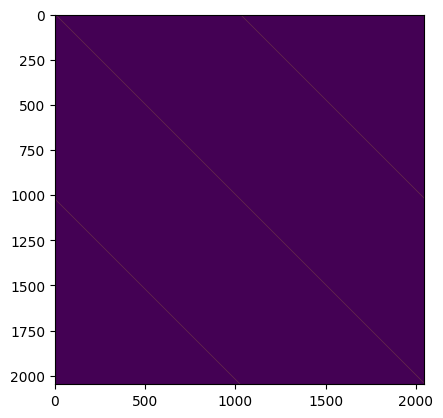

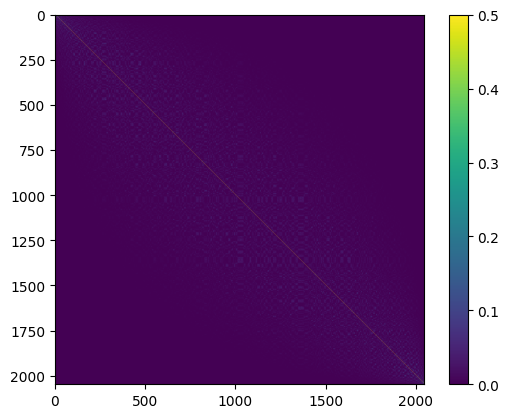

In [3]:
#Hamiltonian
###### Model parameters
#Length of chain
L = 11
J = 1
h0 = 0
basis = spin_basis_1d(L, pauli = -1)

NN_sigma_x = [ [-J, i, (i+1)%L] for i in range(L)]
sigma_z = [ [-1, i] for i in range(L)]

#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]

#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
#H = H.tohamiltonian(params_dict)
#Find eigenvalues
E,V = np.linalg.eigh(H.todense())
#Convert matrix to array
V = np.array(V)
#H = array(H.todense())
p1 = fin_string(1,"x")
for i in range(len(E)):
    v = V[:,i]
    print(np.vdot(v,p1@v))
imshow(np.abs(p1))
show()
imshow(np.abs(V.T@p1@V))
colorbar()

In [8]:
from quspin.tools.evolution import evolve

# quench time
tau = 10.0

# time-dependent Hamiltonian callback
def H_t(t, psi, H0, Quench, tau):
    h_t = 1.0 - t/tau
    return 1j*(H0 ).dot(psi)

# split static pieces once
H0_mat     = H.tohamiltonian(dict(H0=1, Quench=0)).tocsr()
Quench_mat = H.tohamiltonian(dict(H0=0, Quench=1)).tocsr()

# initial state: ground state at t=-tau (i.e. h=1-(-tau)/tau=2)
h_init = 100
H_init = (H0_mat + h_init*Quench_mat).todense()
E0, V0 = np.linalg.eigh(H_init)
psi0 = np.array(V0[:,0])        # ground state

# time grid
times = np.linspace(0, tau, 4001)

# evolve
psi_t = evolve(
    psi0,
    times[0],
    times,
    H_t,
    f_params=(H0_mat, Quench_mat, tau),
    iterate=False
)  # psi_t has shape (len(times), dim)

Pz = array(fin_string(4,"z"))

Px = fin_string(2,"x")

In [21]:
# initial state: ground state at t=-tau (i.e. h=1-(-tau)/tau=2)
h_init = .2
H_init = (H0_mat + h_init*Quench_mat).todense()
E0, V0 = np.linalg.eigh(H_init)
psi0 = np.array(V0[:,0])  
gf = 2
Hf = H0_mat + gf*Quench_mat   # = H0_mat

times = np.linspace(0, 1, 401)

def H_t(t, psi, Hf):
    return 1j*Hf.dot(psi)

psi_t = evolve(
    psi0,
    times[0],
    times,
    H_t,
    f_params=(Hf,),
    iterate=False
)

psi_t = np.squeeze(psi_t)          # -> (1024, 401)
psi_t = psi_t.T    
                # -> (401, 1024)

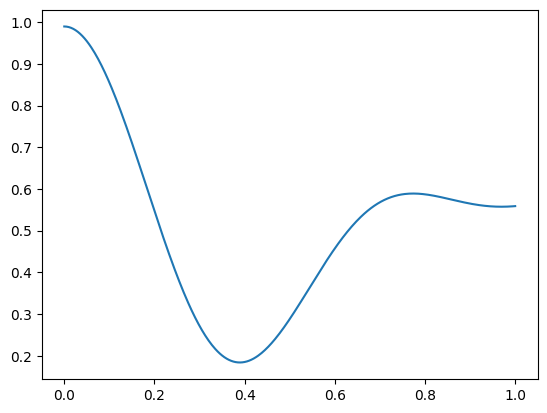

In [22]:

Vt = [ p for p in psi_t]                     # -> (1024,)
plot(times,[(np.vdot(v ,Px@ v)-1/4)*4 for v in Vt])
#plt.ylim(0,1/2)



In [ ]:
for psi in psi_t:
    print(np.vdot(psi,Pz@psi))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 1024)